In [ ]:
from typing import List, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import spacy
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.base import BaseEstimator, TransformerMixin

In [56]:
def lemmatize_with_spacy(texts: Union[List[str], str], 
    model: str = 'en_core_web_sm',
    remove_stopwords: bool = True,
    allowed_pos: tuple = ('NOUN', 'VERB', 'ADJ', 'ADV'),
    min_length: int = 2) -> Union[List[str], str]:

    nlp = spacy.load(model)
    
    def process_text(text):
        doc = nlp(text)
        tokens = []
        for token in doc:
            if remove_stopwords and token.is_stop:
                continue

            if allowed_pos and token.pos_ not in allowed_pos:
                continue

            if token.is_punct or token.is_space:
                continue
            tokens.append(token.lemma_)
        return ' '.join([token for token in tokens if len(token) >= min_length])
    
    if isinstance(texts, str):
        return process_text(texts)
    return [process_text(t) for t in texts]

class LemmatizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, remove_stopwords=True, **kwargs):
        self.remove_stopwords = remove_stopwords
        self.kwargs = kwargs
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return lemmatize_with_spacy(X, remove_stopwords=self.remove_stopwords, **self.kwargs)

In [57]:
def plot_newsgroup_histogram(train_data, test_data):
    bar_width = 0.35
    gap = 0.1

    n_groups = len(train_data.target_names)
    train_counts = np.bincount(train_data.target, minlength=n_groups)
    test_counts = np.bincount(test_data.target, minlength=n_groups)

    group_width = 2 * bar_width + gap
    indices = np.arange(n_groups) * group_width

    plt.figure(figsize=(8, 6))
    plt.bar(indices, train_counts, bar_width, label='Train Data', alpha=0.8)
    plt.bar(indices + bar_width, test_counts, bar_width, label='Test Data', alpha=0.8)

    plt.xticks(indices + bar_width/2, train_data.target_names, rotation=90)
    plt.xlabel('Newsgroup')
    plt.ylabel('Number of Articles')
    plt.title('Number of Articles per Newsgroup')
    plt.legend()
    plt.tight_layout()
    plt.show()

Number of training samples: 11314
Number of test samples: 7532


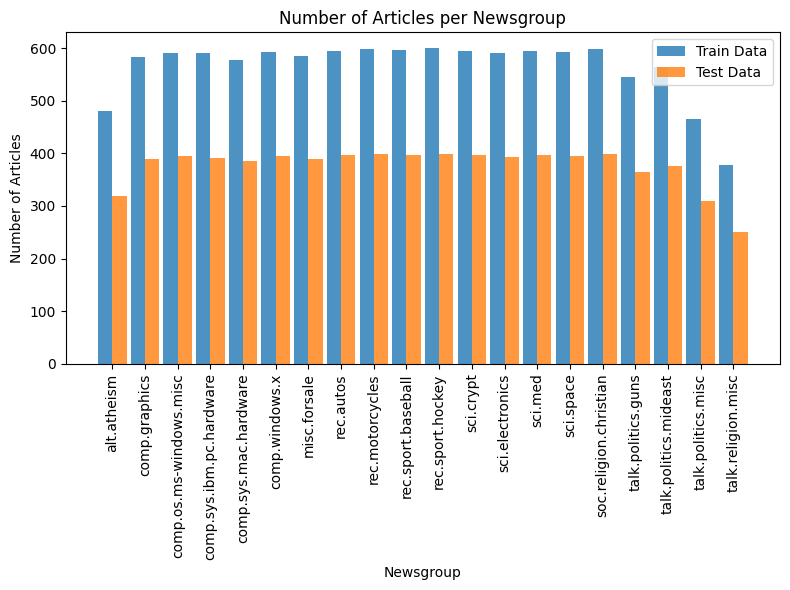

In [58]:
train_data = fetch_20newsgroups(subset='train', shuffle=True, random_state=44)
test_data = fetch_20newsgroups(subset='test', shuffle=True, random_state=44)

print(f"Number of training samples: {len(train_data.data)}")
print(f"Number of test samples: {len(test_data.data)}")

plot_newsgroup_histogram(train_data, test_data)

In [59]:
X_train, y_train = train_data.data, train_data.target
X_test, y_test = test_data.data, test_data.target

In [ ]:
pipeline = Pipeline([
    # ('lemmatizer', LemmatizerTransformer()),
    ('tfidf', TfidfVectorizer(stop_words='english')), 
    ('clf', LinearSVC(dual='auto', random_state=42))
    # ('clf', SGDClassifier(dual='auto', random_state=42))
    # ('clf', LogisticRegression(dual='auto', random_state=42))
    
])

param_grid = {
    # 'lemmatizer__remove_stopwords': [True, False],
    # 'lemmatizer__min_length': [2, 3],
    # 'tfidf__ngram_range': [(1, 1), (1, 2)],
    # 'tfidf__sublinear_tf': [True, False],
    # 'clf__C': [0.1, 1, 10],
    'tfidf__ngram_range': [(1, 2)],
    'tfidf__sublinear_tf': [True],
    'clf__C': [10],
}

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    n_jobs=-1, 
    verbose=1,
    scoring='accuracy'
)

In [61]:
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


{'clf__C': 10, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [62]:
best_model = grid_search.best_estimator_

kft = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X_test, y_test, cv=kft, n_jobs=-1)

print(scores)
print(np.mean(scores))

[0.92966158 0.91838089 0.90836653 0.93824701 0.9309429 ]
0.9251197818766957
